In [1]:
!nvidia-smi

Fri Jul  3 22:33:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch
import torch.nn as nn # nn contains all of pytorch building blocks for neural networks
import matplotlib.pyplot as plt
# check pytorch version
torch.__version__

'2.11.0+cu128'

## 1. Data (Preparing & Loading)

1. Get data into numerical representation
2. Build a model to learn patterns in that numerical representation

We'll use a linear regression formula to make a straight line using *known* **parameters**.

In [3]:
# Create known parameters
weight = 0.7
bias = 0.3

# Create data
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1) # make it matrix
y = weight * X + bias

X[:10], y[:10], len(X), len(y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

### Splitting data into train and test sets

In [4]:
# Create train/test split
train_split = int(0.8 * len(X)) # 40 samples
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

Visualize data

In [5]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  """
  Plots train, test data and compares predictions
  """
  plt.figure(figsize=(10, 7))
  # Plot the train data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show legend
  plt.legend(prop={"size": 14})

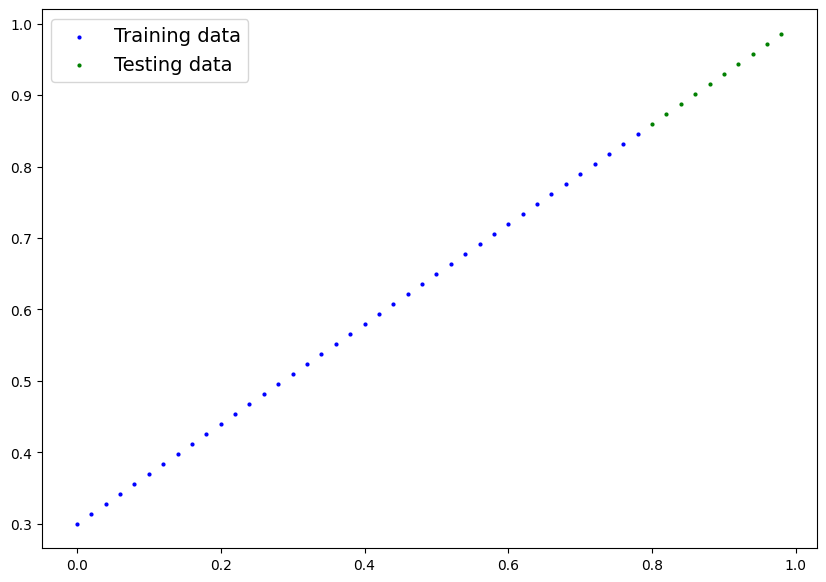

In [6]:
plot_predictions()

## 2. Build Model

* Start with random values (weight & bias)
* Look at the training data and adjust the random values to better represent (or get closer) to the ideal values.

How does it do that?
1. Gradient Descent
2. Backpropagation

In [7]:
from numpy import dtype
# y = wX + b
# Create a linear regression model

class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    out = self.weights * x + self.bias
    return out


### PyTorch model building essentials

* torch.nn - contains all the building blocks for computational graph (NN can be considered a comp graph)
* torch.nn.Parameter - what parameters should our model try and learn. Often a PyTorch layer from torch.nn will set this for us.
* torch.nn.Module - Base class for all NN modules. If you subclass it, you should override forward method.
* torch.optim - Optimizers in PyTorch live, they will help with gradient descent

In [8]:
# torch.manual_seed(42)
# torch.randn(1)

### Checking contents of our PyTorch model

In [9]:
# Create a random seed
torch.manual_seed(42) # for sake of reproducibility of results

# Create an instance of the model (sub-class of nn.Module)
model_0 = LinearRegressionModel()
# Checkout parameters
# list(model_0.parameters())
model_0.state_dict() # List named parameters

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making predictions using `torch.inference_mode()`

To check out model's predictive power, lets see how well it predicts `y_test` based on `X_test`.

In [10]:
# with torch.inference_mode():
with torch.no_grad():
  y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

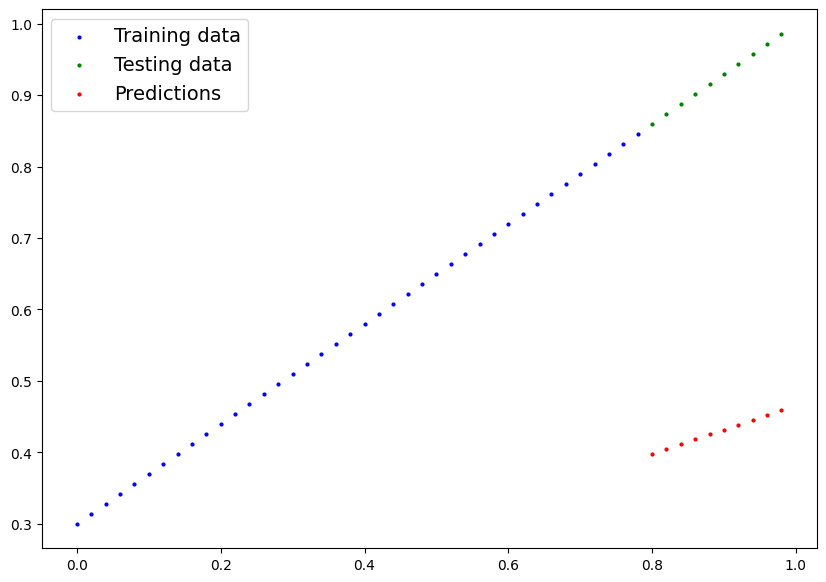

In [11]:
plot_predictions(predictions=y_preds)

### 3. Train Model

Idea: Model to move from some unknown parameters (random) to some known parameters.

One way to measure how poor our predictions are, we need to use loss functions. Loss function can also be called cost function or criterion in different areas.

* **Loss function:** A function to measure how wrong your model's predictions are to the ideal outputs. So lower is better!
* **Optimizer:** Takes into account the loss of a model and adjusts model's parameters (weight & bias)

We need:
* Train loop
* Test loop

In [12]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [13]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [14]:
# Setup a loss function
loss_fn = nn.L1Loss() # torch.mean(torch.abs(y_pred - y_test))

# Setup an optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01) # lr is most important hyperparameter we can set

### Build a train, test loop in PyTorch

Train loop:
0. Loop through the data
1. forward pass
2. Calculate loss
3. Optimizer zero grad
4. Loss backward - compute gradients (loss w.r.t parameters) (backpropagation)
5. Optimizer step - adjust model's parameters (gradient descent)


In [15]:
torch.manual_seed(42)

# An epoch is one loop through the data
epochs = 200

# Track different values
epoch_count = []
loss_values = []
test_loss_values = []

for epoch in range(epochs):
  model_0.train() # put model to train model (to compute and save gradients)

  y_pred = model_0(X_train) # forward pass
  loss = loss_fn(y_pred, y_train) # calculate loss
  optimizer.zero_grad() # clear the gradients
  loss.backward() # backprop
  optimizer.step() # update parameters

  model_0.eval() # turn off gradient tracking
  with torch.no_grad():
    test_pred = model_0(X_test) # forward pass
    test_loss = loss_fn(test_pred, y_test) # calculate loss

  if epoch % 10 == 0 or epoch == epochs - 1:
    # append values to track
    epoch_count.append(epoch)
    loss_values.append(loss.item())
    test_loss_values.append(test_loss)
    # Print imp values
    print(f"Epoch: {epoch} | Loss: {loss:.04f} | Test loss: {test_loss:.04f}")
    print(model_0.state_dict())


Epoch: 0 | Loss: 0.3129 | Test loss: 0.4811
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
Epoch: 10 | Loss: 0.1977 | Test loss: 0.3464
OrderedDict({'weights': tensor([0.3796]), 'bias': tensor([0.2388])})
Epoch: 20 | Loss: 0.0891 | Test loss: 0.2173
OrderedDict({'weights': tensor([0.4184]), 'bias': tensor([0.3333])})
Epoch: 30 | Loss: 0.0531 | Test loss: 0.1446
OrderedDict({'weights': tensor([0.4512]), 'bias': tensor([0.3768])})
Epoch: 40 | Loss: 0.0454 | Test loss: 0.1136
OrderedDict({'weights': tensor([0.4748]), 'bias': tensor([0.3868])})
Epoch: 50 | Loss: 0.0417 | Test loss: 0.0992
OrderedDict({'weights': tensor([0.4938]), 'bias': tensor([0.3843])})
Epoch: 60 | Loss: 0.0382 | Test loss: 0.0889
OrderedDict({'weights': tensor([0.5116]), 'bias': tensor([0.3788])})
Epoch: 70 | Loss: 0.0348 | Test loss: 0.0806
OrderedDict({'weights': tensor([0.5288]), 'bias': tensor([0.3718])})
Epoch: 80 | Loss: 0.0313 | Test loss: 0.0723
OrderedDict({'weights': tensor([0.5459]), 'b

In [16]:
import numpy as np
loss_values, test_loss_values

([0.31288138031959534,
  0.1976713240146637,
  0.08908725529909134,
  0.053148526698350906,
  0.04543796554207802,
  0.04167863354086876,
  0.03818932920694351,
  0.03476089984178543,
  0.03132382780313492,
  0.02788739837706089,
  0.024458957836031914,
  0.021020207554101944,
  0.01758546568453312,
  0.014155393466353416,
  0.010716589167714119,
  0.0072835334576666355,
  0.0038517764769494534,
  0.008932482451200485,
  0.008932482451200485,
  0.008932482451200485,
  0.0025885067880153656],
 [tensor(0.4811),
  tensor(0.3464),
  tensor(0.2173),
  tensor(0.1446),
  tensor(0.1136),
  tensor(0.0992),
  tensor(0.0889),
  tensor(0.0806),
  tensor(0.0723),
  tensor(0.0647),
  tensor(0.0565),
  tensor(0.0482),
  tensor(0.0406),
  tensor(0.0323),
  tensor(0.0241),
  tensor(0.0165),
  tensor(0.0082),
  tensor(0.0050),
  tensor(0.0050),
  tensor(0.0050),
  tensor(0.0084)])

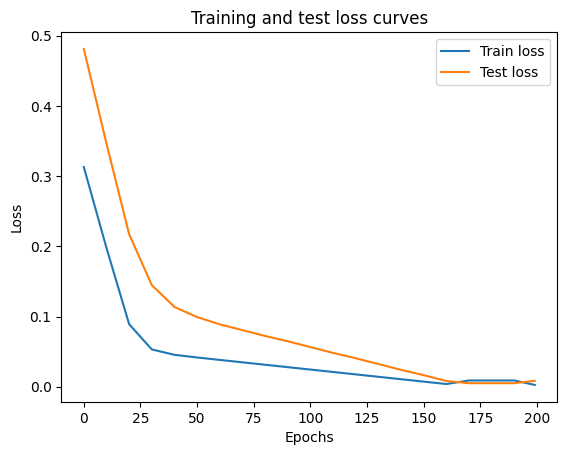

In [17]:
# Plot loss curves
plt.plot(epoch_count, np.array(torch.tensor(loss_values).detach()), label="Train loss") # matplotlib requires numpy.
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

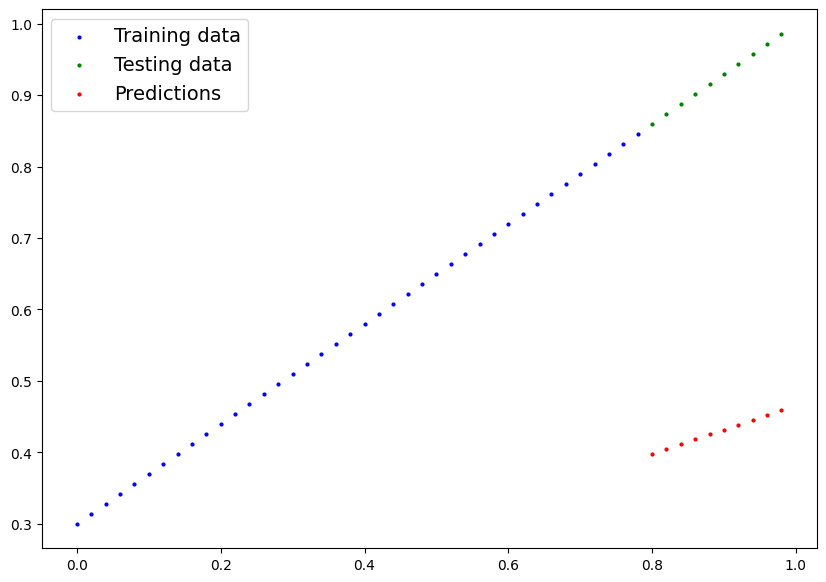

In [18]:
plot_predictions(predictions=y_preds)

In [19]:
with torch.no_grad():
  model_0.eval()
  y_preds_new = model_0(X_test)

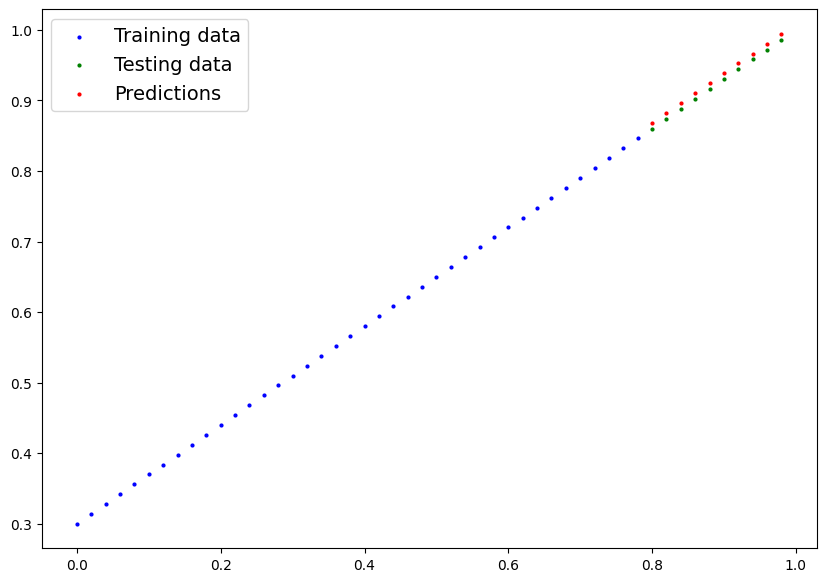

In [20]:
plot_predictions(predictions=y_preds_new)

## Saving a model in PyTorch

3 main methods for saving and loading:
1. `torch.save()` - allows us to save PyTorch object in Python's pickle format
2. `torch.load()` - allows us to load a saved PyTorch object
3. `torch.nn.Module.load_state_dict()` - this allows us to load models saved state dictionary (parameters)

In [21]:
# Save our PyTorch model
from pathlib import Path

# 1. Create a models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pth" # or .pt
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME
MODEL_SAVE_PATH

# 3. Save the model state_dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(model_0.state_dict(), MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model_0.pth


## Loading PyTorch model

Since we saved models `state_dict()` rather than the entire model, we will create a new instance of our model class and load saved `state_dict()`

In [22]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [23]:
# To load a saved state_dict, we have to instantiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()
# Load the saved state_dict of model_0
loaded_model_0.load_state_dict(torch.load(MODEL_SAVE_PATH))

<All keys matched successfully>

In [24]:
# Make some predictions in eval mode
loaded_model_0.eval()

with torch.inference_mode(): # or torch.no_grad()
  loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [25]:
# Compare loaded model preds with original preds
y_preds_new == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## 6. Putting it all together

In [26]:
import torch
import matplotlib.pyplot as plt
import torch.nn as nn

torch.__version__

'2.11.0+cu128'

In [28]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


### 6.1 Data

In [30]:
# Create some data using linear regression formula y = weights * X + bias
weights = 0.7
bias = 0.3

# Create range of values
start = 0
end = 1
step = 0.02

# Create X and y (features and labels)
X = torch.arange(start, end, step).unsqueeze(dim=1) # without unsqueeze errors will pop up
y = weights * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [32]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

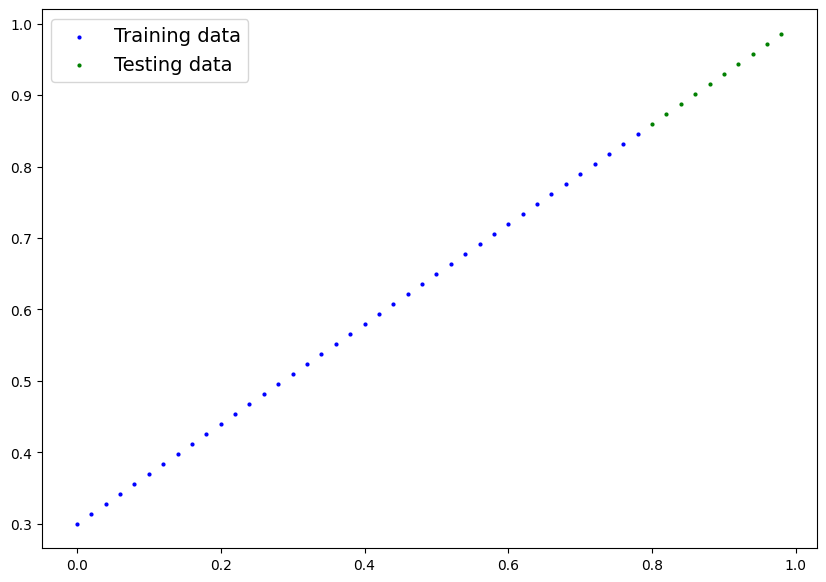

In [33]:
# Plot data
plot_predictions(X_train, y_train, X_test, y_test)

In [34]:
# Build a PyTorch Linear model

class LinearRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    # use nn.Linear for creating model parameters
    self.linear_layer = nn.Linear(in_features=1, out_features=1) # X shape (n, 1)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)


In [54]:
# Set manual seed
torch.manual_seed(42)

model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [55]:
# Check the model current device
next(model_1.parameters()).device

device(type='cpu')

In [56]:
# Set the model to use the target device
model_1.to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

### 6.3 Training

In [57]:
import torch.nn as nn

# Setup loss function
loss_fn = nn.L1Loss()

# Set the optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.01)

In [58]:
torch.manual_seed(42)

epochs = 200

# Put data on the target device
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
  # train
  model_1.train()
  y_pred = model_1(X_train)
  loss = loss_fn(y_pred, y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  # testing
  model_1.eval()
  with  torch.inference_mode(): # or torch.no_grad()
    test_pred = model_1(X_test)
    test_loss = loss_fn(test_pred, y_test)

  if epoch % 10 == 0:
    print(f"Epoch: {epoch}, loss: {loss}, test_loss: {test_loss}")

Epoch: 0, loss: 0.5551779270172119, test_loss: 0.5739762187004089
Epoch: 10, loss: 0.4399681091308594, test_loss: 0.4392664134502411
Epoch: 20, loss: 0.3247582018375397, test_loss: 0.30455657839775085
Epoch: 30, loss: 0.20954833924770355, test_loss: 0.16984669864177704
Epoch: 40, loss: 0.09433844685554504, test_loss: 0.03513690456748009
Epoch: 50, loss: 0.023886388167738914, test_loss: 0.04784907028079033
Epoch: 60, loss: 0.019956795498728752, test_loss: 0.045803118497133255
Epoch: 70, loss: 0.016517987474799156, test_loss: 0.037530567497015
Epoch: 80, loss: 0.013089174404740334, test_loss: 0.02994490973651409
Epoch: 90, loss: 0.009653178043663502, test_loss: 0.02167237363755703
Epoch: 100, loss: 0.006215683650225401, test_loss: 0.014086711220443249
Epoch: 110, loss: 0.00278724217787385, test_loss: 0.005814164876937866
Epoch: 120, loss: 0.0012645035749301314, test_loss: 0.013801801018416882
Epoch: 130, loss: 0.0012645035749301314, test_loss: 0.013801801018416882
Epoch: 140, loss: 0.001

In [59]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

In [64]:
np.array(test_pred.cpu())

array([[0.8599563 ],
       [0.87389255],
       [0.88782877],
       [0.9017649 ],
       [0.9157011 ],
       [0.9296373 ],
       [0.9435735 ],
       [0.95750964],
       [0.9714458 ],
       [0.985382  ]], dtype=float32)

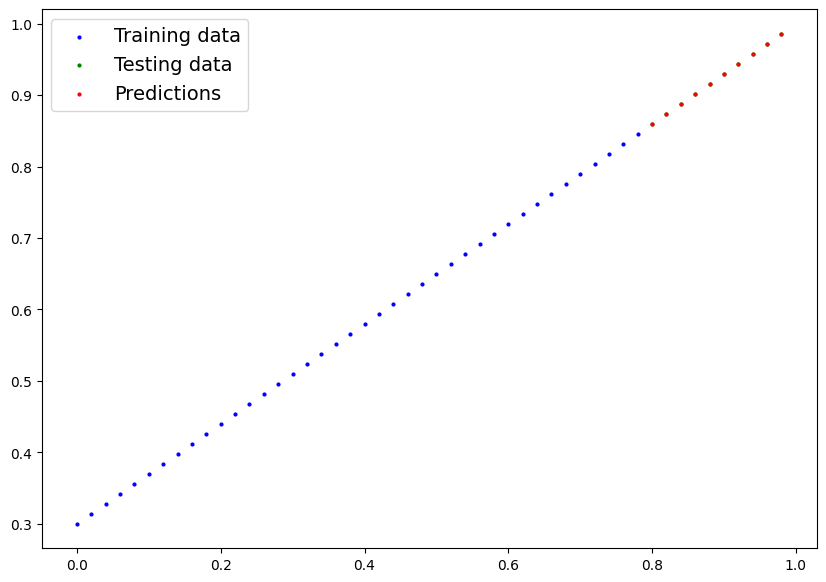

In [66]:
model_1.eval()

with torch.inference_mode():
  y_preds = model_1(X_test)

plot_predictions(predictions=np.array(y_preds.cpu()))

### 6.5 Saving & loading a trained model

In [68]:
from pathlib import Path
MODEL_PATH = Path("models")
Path.mkdir(MODEL_PATH, parents=True, exist_ok=True)

MODEL_NAME = "01_pytorch_workflow_model_1.pth" # or .pt
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME
MODEL_SAVE_PATH

PosixPath('models/01_pytorch_workflow_model_1.pth')

In [69]:
torch.save(model_1.state_dict(), MODEL_SAVE_PATH)

In [74]:
# Load the saved model state_dict()
loaded_model_1 = LinearRegressionModelV2()
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))
loaded_model_1.to(device) # Put loaded model to device
next(loaded_model_1.parameters()).device

device(type='cuda', index=0)

In [76]:
# Evaluate loaded model
loaded_model_1.eval()
with torch.inference_mode():
  loaded_model_1_preds = loaded_model_1(X_test)

y_preds == loaded_model_1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')